In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

__Objective 1: Import the data from both tabs in the "Bank_Churn_Messy" Excel file__

In [2]:
#reading both sheets from excel
bank_churny_messy_file = pd.ExcelFile("Bank_Churn_Messy.xlsx")
customer_info = pd.read_excel(bank_churny_messy_file, "Customer_Info")
account_info = pd.read_excel(bank_churny_messy_file, "Account_Info")

__Objective 1: Use a left join to join "Account_Info" to "Customer_Info" using the CustomerID column__

In [3]:
#left join account_info with customer_info
left_join_info = pd.merge(customer_info, account_info, how='left', on='CustomerId')

__Objective 1: Check for and remove duplicate rows and columns__

In [4]:
#1st we group the CustomerIds based on their counts
group_customers = left_join_info.groupby(by='CustomerId').size()

#now we filter the series by the records that have a count greater than 1 so we know there are duplicate entries
group_customers_filtered = group_customers[group_customers > 1]

#counting duplicates
print (left_join_info.duplicated(subset='CustomerId').sum())


#we drop the duplicate rows 
left_join_info = left_join_info.drop_duplicates(subset='CustomerId', keep='first')

#checking if the columns tenure_x and tenure_y hold the same values.
left_join_info['Tenure_x'].equals(left_join_info['Tenure_y'])
#the above check returned true, meaning we have repeated columns 
#we are going to drop column 'Tenure_y' and rename column 'Tenure_x' to 'Tenure'
left_join_info = left_join_info.drop(columns=['Tenure_y'])
left_join_info = left_join_info.rename(columns={'Tenure_x' : 'Tenure'})


4


In [5]:
#checking data types
left_join_info.head(n=5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1,€125510.82,1,Yes,Yes,0


__Objective 2: Check the data types for each column and make any necessary fixes and Replace missing values in categorical columns with "MISSING", and missing values in numeric columns with the median__

In [6]:
#first let's check the datatypes of each column
left_join_info.dtypes

#on balance column, remove the € symbol. Same on EstimatedSalary column. 
left_join_info['Balance'] = left_join_info['Balance'].str.replace('€', '', regex = True)
left_join_info['EstimatedSalary'] = left_join_info['EstimatedSalary'].str.replace('€', '', regex = True)

#on Salary and Balance column, turn data type into a float 
left_join_info = left_join_info.astype({"Balance": "float64"})
left_join_info = left_join_info.astype({"EstimatedSalary": "float64"})

#check whether there are missing values 
left_join_info.isna().sum()

#replace null surnames with "MISSING"
left_join_info['Surname'] = left_join_info['Surname'].fillna('MISSING')

#finding the median for the age column and subbing missing values by median
median_age = left_join_info['Age'].median()
left_join_info['Age'] = left_join_info['Age'].fillna(median_age)

#on age column, switch data type from float to int. 
left_join_info = left_join_info.astype({"Age": "int64"})

#on Exited column, switch the 0/1 to boolean True/False
left_join_info = left_join_info.astype({"Exited": "bool"})

#-on HasCrCard and IsActiveMember columns, change it to a boolean 
left_join_info['HasCrCard'] = left_join_info['HasCrCard'] == 'Yes'
left_join_info['IsActiveMember'] = left_join_info['IsActiveMember'] == 'Yes'

left_join_info.dtypes
#left_join_info.head(n=5)

#-on geography column, record that says FRA or French, i switch it to France

CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
EstimatedSalary    float64
Balance            float64
NumOfProducts        int64
HasCrCard             bool
IsActiveMember        bool
Exited                bool
dtype: object

__Objective 2: Profile the numeric columns in the data. Are there any extreme or non-sensical values? If so, impute them with the median of the column.__

In [7]:
#let's describe our dataframe statistically
left_join_info.describe()

#computing the median for the EstimatedSalary values
median_estimated_salary = left_join_info['EstimatedSalary'].median()

#imputing the median onto the negative values of EstimatedSalary
left_join_info.loc[left_join_info['EstimatedSalary'] < 0, 'EstimatedSalary'] = median_estimated_salary



__Objective 2: Combine any variations in country names in the "Geography" column to a single value per country__

In [8]:
#seeing unique values in Geography column
left_join_info['Geography'].unique()

#substituting FRA/French by France
left_join_info['Geography'] = np.where((left_join_info['Geography'] == 'FRA' )| (left_join_info['Geography'] == 'French'), 'France', left_join_info['Geography'])

__Objective 3: Build a bar chart displaying the count of churners (Exited=1) vs. non-churners (Exited=0)__

<Axes: xlabel='Characterization', ylabel='Frequency'>

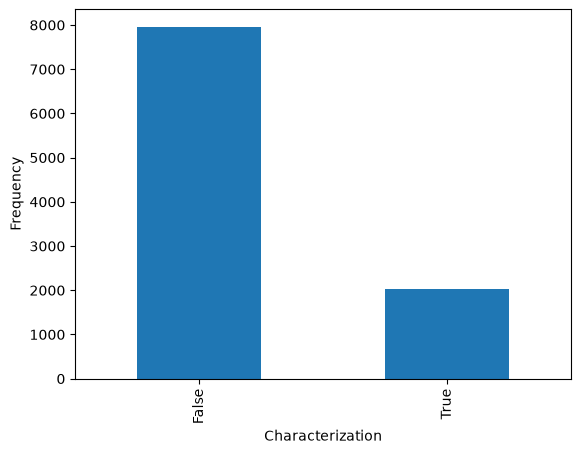

In [9]:
#Counting churners (Exited = True) and non-churners (Exited = False)
count = left_join_info['Exited'].value_counts()

#building a bar chart using these values
count.plot.bar(xlabel= 'Characterization', ylabel='Frequency')

__Objective 3:Explore the categorical variables vs. the target, and look at the percentage of Churners by “Geography” and “Gender”__

<Axes: xlabel='Gender', ylabel='Percentage'>

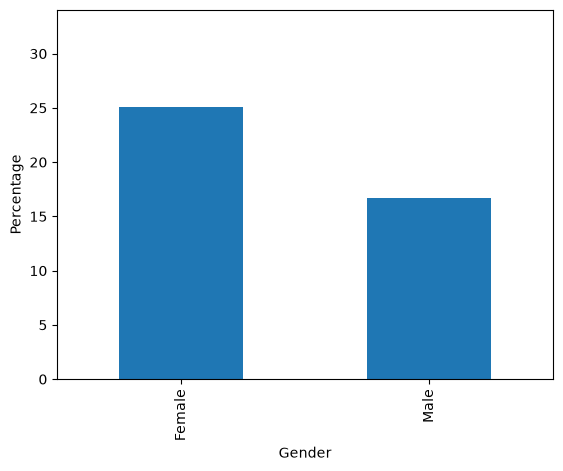

In [10]:
#from the total number of people from each country and genders, we want to see the percentage of people churning
#eg: %french churners = (number of people that churned in france / total people from france) * 100
#then we'll plot a bar plot. since the parameters are similar for both Geography and gender we'll write up a function

def plot_categorical_churners (data_frame, column_name):
    out_dict = {}

    for categorical_record in data_frame[column_name].unique():
        categorical_records_dataframe = data_frame[data_frame[column_name] == categorical_record]
        count_categorical_records = len (categorical_records_dataframe)
        count_churners = len (categorical_records_dataframe[categorical_records_dataframe['Exited'] == True])
        percentage_categorical_record_churners = round ((count_churners / count_categorical_records) * 100 , 2)
        out_dict[categorical_record] = percentage_categorical_record_churners

    #since a dictionary has no .plot method, we need to convert it to a series
    out_series = pd.Series(out_dict)
    
    return out_series.plot.bar(xlabel = column_name, ylabel = 'Percentage')

plot_categorical_churners (left_join_info, 'Geography')
plot_categorical_churners (left_join_info, 'Gender')



__Objective 3:Build box plots for each numeric field, broken out by churners vs. non-churners__

C:\Users\iliya\AppData\Local\Temp\ipykernel_26412\80297824.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[idx].set_xticklabels(['Non-Churned','Churned'])
C:\Users\iliya\AppData\Local\Temp\ipykernel_26412\80297824.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[idx].set_xticklabels(['Non-Churned','Churned'])
C:\Users\iliya\AppData\Local\Temp\ipykernel_26412\80297824.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs[idx].set_xticklabels(['Non-Churned','Churned'])
C:\Users\iliya\AppData\Local\Temp\ipykernel_26412\80297824.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

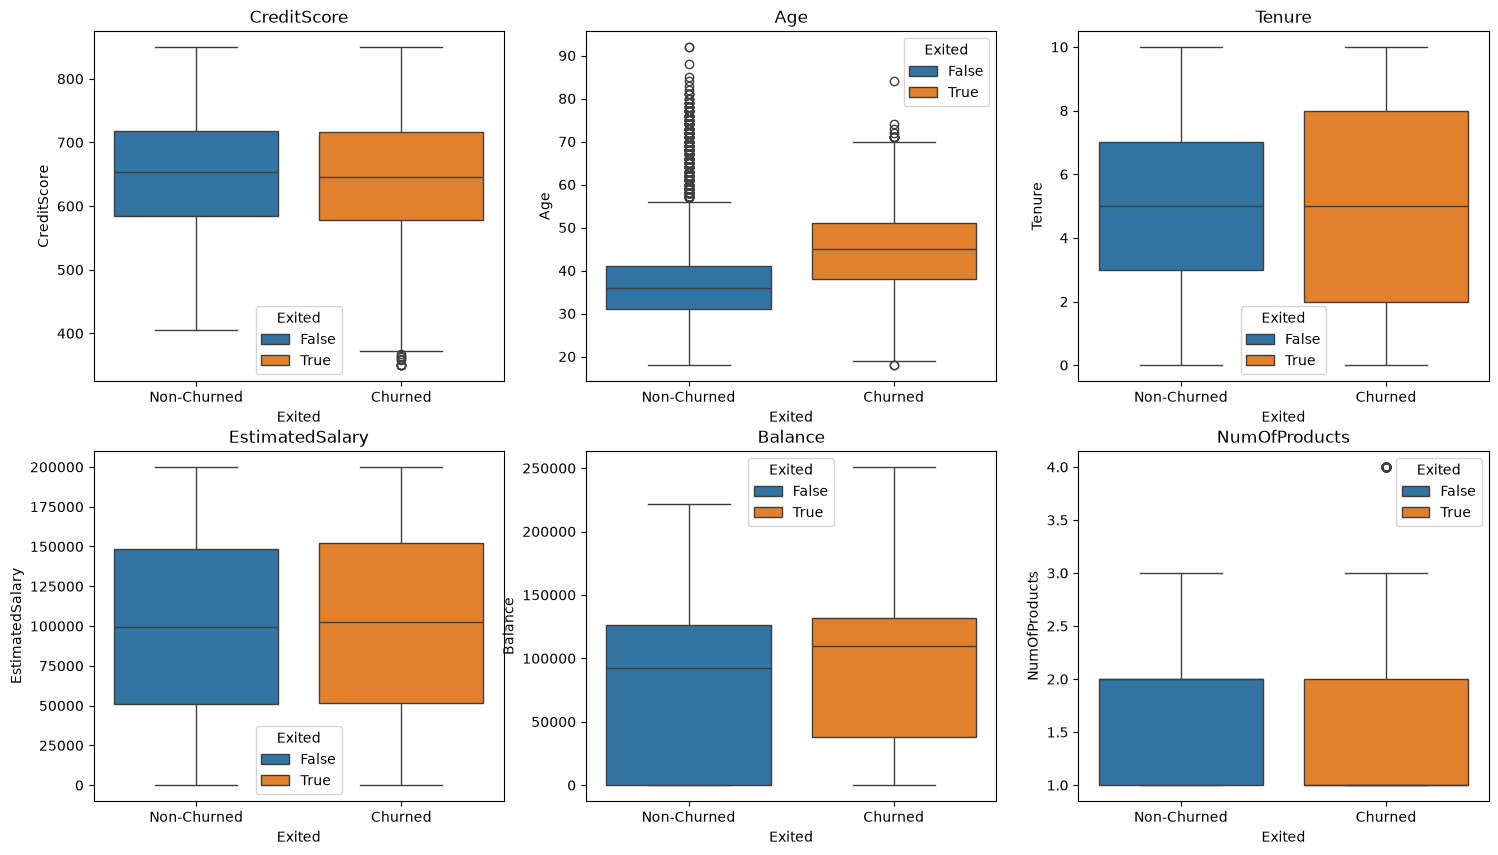

In [11]:
#Numeric fields: CreditScore, Age, Tenure, EstimatedSalary, Balance, NumOfProducts
#for a box plot , I need to calculate the min, Q1 (lower quartile), median, Q3 (upper quartile) and max. though i think the box plot does this itself

numeric_fields = ['CreditScore', 'Age', 'Tenure', 'EstimatedSalary', 'Balance', 'NumOfProducts']

#creating 2x3 subplot
fig, axs = plt.subplots(2,3, figsize=(18,10))
axs = axs.flatten()
for idx, col in enumerate(numeric_fields):
        sns.boxplot(left_join_info, x='Exited', y=col, ax=axs[idx], hue='Exited')
        axs[idx].set_xticklabels(['Non-Churned','Churned'])
        axs[idx].set_title(col)

plt.show()





__Objective 3: Build histograms for each numeric field, broken out by churners vs. non-churners__

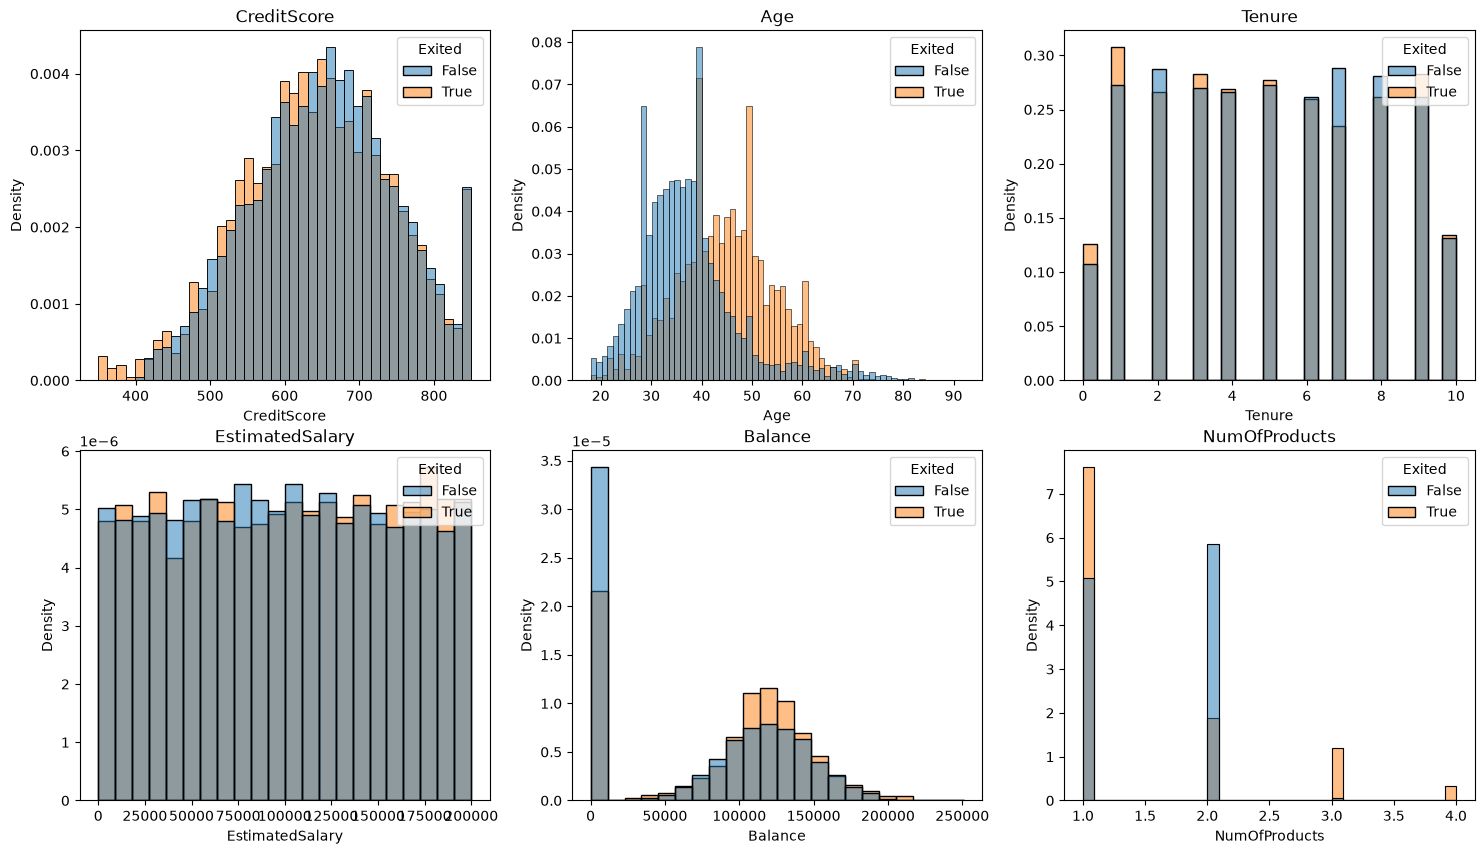

In [12]:
fig, axs = plt.subplots(2,3, figsize=(18,10))
axs = axs.flatten()
for idx, col in enumerate(numeric_fields):
    sns.histplot(left_join_info, x=col, ax=axs[idx], hue='Exited', stat='density', common_norm=False)
    axs[idx].set_title(numeric_fields[idx])

plt.show()


__Objective 4: Create a new dataset that excludes any columns that aren't suited for modelling__

In [13]:
#so we'll look at columns that do not affect churn
#CustomerId and surname do not affect churn, so we'll drop them
left_join_info = left_join_info.drop(['CustomerId','Surname'], axis=1)
left_join_info.head()

,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,619,France,Female,42,2,101348.88,0.00,1,True,True,True
2,608,Spain,Female,41,1,112542.58,83807.86,1,True,True,False
3,502,France,Female,42,8,113931.57,159660.80,3,False,False,True
4,699,France,Female,39,1,93826.63,0.00,2,False,False,False
5,850,Spain,Female,43,2,79084.10,125510.82,1,True,True,False


__Objective 4:Create dummy variables for categorical fields__

In [ ]:
# Convert text categories (Geography, Gender) into True/False dummy columns,
# since models only work with numbers.
# drop_first=True drops one category per column (France, Female) to avoid
# redundant columns (the dummy variable trap). The dropped category is the
# baseline: all False means France / Female.
left_join_info = pd.get_dummies(left_join_info, drop_first=True)

left_join_info.head()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,101348.88,0.00,1,True,True,True,False,False,False
2,608,41,1,112542.58,83807.86,1,True,True,False,False,True,False
3,502,42,8,113931.57,159660.80,3,False,False,True,False,False,False
4,699,39,1,93826.63,0.00,2,False,False,False,False,False,False
5,850,43,2,79084.10,125510.82,1,True,True,False,False,True,False


__Objective 4:Create a new “balance_v_income” feature, which divides a customer’s bank balance by their estimated salary, then visualize that feature vs. churn status__

In [17]:
left_join_info['Balance_vs_Salary'] = left_join_info['Balance'] / left_join_info['EstimatedSalary']
left_join_info.head()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_Germany,Geography_Spain,Gender_Male,Balance_vs_Salary
0,619,42,2,101348.88,0.00,1,True,True,True,False,False,False,0.000000
2,608,41,1,112542.58,83807.86,1,True,True,False,False,True,False,0.744677
3,502,42,8,113931.57,159660.80,3,False,False,True,False,False,False,1.401375
4,699,39,1,93826.63,0.00,2,False,False,False,False,False,False,0.000000
5,850,43,2,79084.10,125510.82,1,True,True,False,False,True,False,1.587055


<Axes: ylabel='Balance_vs_Salary'>

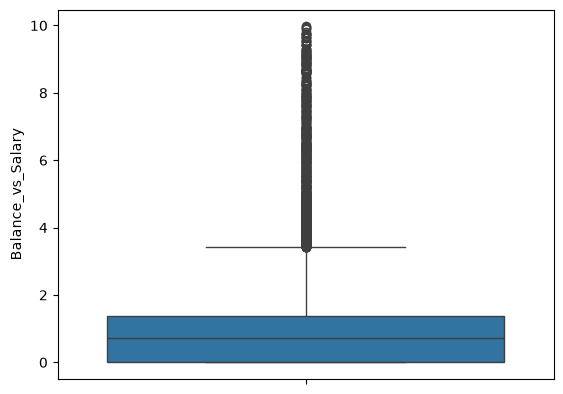

In [21]:
sns.boxplot(data=left_join_info.query('Balance_vs_Salary < 10'), y='Balance_vs_Salary')

In [19]:
left_join_info.describe()

,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Balance_vs_Salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921500,5.012800,100092.252507,76485.889288,1.530200,3.878703
std,96.653299,10.487552,2.892174,57510.146401,62397.405202,0.581654,108.337260
min,350.000000,18.000000,0.000000,11.580000,0.000000,1.000000,0.000000
25%,584.000000,32.000000,3.000000,51002.110000,0.000000,1.000000,0.000000
50%,652.000000,37.000000,5.000000,100196.062500,97198.540000,1.000000,0.747002
75%,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,1.514022
max,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,10614.655440


<Axes: ylabel='Balance_vs_Salary'>

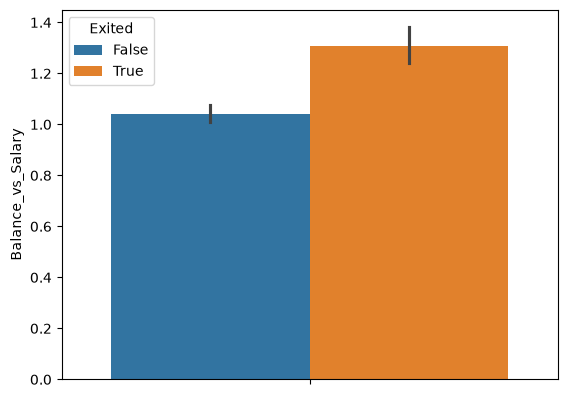

In [22]:
sns.barplot(data=left_join_info.query('Balance_vs_Salary < 10'), y='Balance_vs_Salary', hue='Exited')